# INFO 4871/5871: Web Data Science
## Week 06 - Archived web pages

[Brian C. Keegan, Ph.D.](http://brianckeegan.com/)  
[Assistant Professor, Department of Information Science](https://www.colorado.edu/cmci/people/information-science/brian-c-keegan)  
University of Colorado Boulder  

Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

We'll need a few common libraries for all these examples.

In [1]:
# Lets us talk to other servers on the web
import requests

# APIs spit out data in JSON
import json

# Space out our requests
from time import sleep

# Use BeautifulSoup to parse some HTML
from bs4 import BeautifulSoup

# Safetly quoting strings for URLs
from urllib.parse import unquote, quote

# Handling dates and times
from datetime import datetime

# DataFrames!
import pandas as pd
import numpy as np

# Data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sb

Now we'll leave some of the ethically-fraught methods of web scraping behind. The Internet Archive maintains the "[Wayback Machine](https://www.archive.org/web/)" where old versions of websites are stored. Some of my favorites:

* [CNN in June 2000](https://web.archive.org/web/20000815052826/http://www.cnn.com/)
* [Facebook in August 2004](https://web.archive.org/web/20040817020419/http://www.facebook.com/)
* [Apple in April 1997](https://web.archive.org/web/19970404064444/http://www.apple.com:80/)

In these URLs above, there is a numeric identifier corresponding to the timestamp when the image of the website was captured. How do we know when the Wayback Machine archived a webpage? There's a free and open API ([docs](https://archive.org/help/wayback_api.php))!

## Using the Wayback Machine API

The simplest API request we can make asks for the most recent snapshot of a webpage archived by the Wayback Machine.

In [2]:
wb_url = 'http://archive.org/wayback/available?url=facebook.com'

wb_response = requests.get(wb_url)

wb_response.json()

{'url': 'facebook.com',
 'archived_snapshots': {'closest': {'status': '200',
   'available': True,
   'url': 'http://web.archive.org/web/20241008112935/https://www.facebook.com/',
   'timestamp': '20241008112935'}}}

This response tells us the timestamp and location of this snapshot, which we could then go retrieve and parse.

In [3]:
wb_response_json = wb_response.json()

recent_fb_wb_url = wb_response_json['archived_snapshots']['closest']['url']

recent_fb_wb_response = requests.get(recent_fb_wb_url)

Get the raw text out, soupify, and look for links.

In [4]:
recent_fb_wb_raw = recent_fb_wb_response.text

recent_fb_wb_soup = BeautifulSoup(recent_fb_wb_raw)

[link.text for link in recent_fb_wb_soup.find_all('a')]

['Helmut',
 '',
 'Mark',
 '',
 'Jackson',
 '',
 'Vangelis',
 '',
 'Add Account',
 '',
 'Forgotten password?',
 'Create new account',
 'Create a Page',
 'اردو',
 'پښتو',
 'العربية',
 'हिन्दी',
 'বাংলা',
 'ਪੰਜਾਬੀ',
 'فارسی',
 'ગુજરાતી',
 'Deutsch',
 'Español',
 '',
 'Sign Up',
 'Log in',
 'Messenger',
 'Facebook Lite',
 'Video',
 'Places',
 'Games',
 'Marketplace',
 'Meta Pay',
 'Meta Store',
 'Meta Quest',
 'Ray-Ban Meta',
 'Meta AI',
 'Instagram',
 'Threads',
 'Fundraisers',
 'Services',
 'Voting Information Centre',
 'Privacy Policy',
 'Privacy Centre',
 'Cookie settings',
 'Groups',
 'About',
 'Create ad',
 'Create Page',
 'Developers',
 'Careers',
 'Cookies',
 'AdChoices',
 'Terms',
 'Help',
 'Contact uploading and non-users',
 'Settings',
 'Activity log']

We can also ask for the most recent snapshot of a webpage around a specific date. Let's ask the Wayback Machine for a snapshot of Facebook around February 1, 2008.

In [10]:
wb_url = 'http://archive.org/wayback/available?url=twitter.com/realdonaldtrump&timestamp=20110201'

wb_response = requests.get(wb_url)

wb_response_json = wb_response.json()

wb_response_json

{'url': 'twitter.com/realdonaldtrump',
 'archived_snapshots': {'closest': {'status': '200',
   'available': True,
   'url': 'http://web.archive.org/web/20110216140429/http://twitter.com/realDonaldTrump',
   'timestamp': '20110216140429'}},
 'timestamp': '20110201'}

Note that this is a relatively deep JSON object we have to navigate into to access information like the Wayback URL or the timestamp of the snapshot. The closest snapshot to February 1, 2008 was January 30, 2008. We use the [`datetime.strptime`](https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior) function to turn this numeric string that we recognize as a timestamp into a datetime object.

In [11]:
wb_response_json['archived_snapshots']['closest']['timestamp']

'20110216140429'

In [12]:
print(
    datetime.strptime(
        wb_response_json['archived_snapshots']['closest']['timestamp'],
        '%Y%m%d%H%M%S'
    )
)

2011-02-16 14:04:29


As before, we could scrape out the links on this 2008 version of the page.

In [15]:
fb_wb_soup.find_all('span',{'class':'entry-content'})

[<span class="entry-content">From The Desk Of Donald Trump 2/15/10- <a class="tweet-url web" href="http://web.archive.org/web/20110216140429/http://www.youtube.com/watch?v=YkOzIFWWJ3o" rel="nofollow" target="_blank">http://www.youtube.com/watch?v=YkOzIFWWJ3o</a></span>,
 <span class="entry-content">Check out ShouldTrumpRun....<a class="tweet-url web" href="http://web.archive.org/web/20110216140429/http://shouldtrumprun.com/" rel="nofollow" target="_blank">http://shouldtrumprun.com/</a></span>,
 <span class="entry-content">FoxNewsInsider with comments on my speech at CPAC in Washington, DC <a class="tweet-url web" href="http://web.archive.org/web/20110216140429/http://www.youtube.com/watch?v=V96ftZPpIcw" rel="nofollow" target="_blank">http://www.youtube.com/watch?v=V96ftZPpIcw</a></span>,
 <span class="entry-content">I was on CNN yesterday.....<a class="tweet-url web" href="http://web.archive.org/web/20110216140429/http://www.youtube.com/watch?v=hBp8N8706qA" rel="nofollow" target="_blan

In [13]:
# Find the old URL
fb_wb_url = wb_response_json['archived_snapshots']['closest']['url']

# Go get the archived snapshot from the Wayback Machine
fb_wb_response = requests.get(fb_wb_url)

# Get the text from the response
fb_wb_raw = fb_wb_response.text

# Soup-ify
fb_wb_soup = BeautifulSoup(fb_wb_raw)

# Make a list of the text of the links
[link.text for link in fb_wb_soup.find_all('a')]

['Skip past navigation',
 'm.twitter.com',
 'Skip to navigation',
 'Skip to sign in form',
 '\n\n',
 'Sign in',
 'Forgot password?',
 'Forgot username?',
 'Already using Twitter on your phone?',
 'Join today',
 '\nCodes for other countries\n',
 '',
 'http://www.youtube.com/watch?v=YkOzIFWWJ3o',
 '\nabout 12 hours ago',
 'http://shouldtrumprun.com/',
 '\nabout 16 hours ago',
 'http://www.youtube.com/watch?v=V96ftZPpIcw',
 '\nabout 20 hours ago',
 'http://www.youtube.com/watch?v=hBp8N8706qA',
 '\nabout 20 hours ago',
 'http://www.youtube.com/watch?v=PR1b8yKxcAo',
 '\n6:50 AM Feb 11th',
 '\n10:29 AM Feb 10th',
 'trump2009mlm',
 'http://bit.ly/gE25Hx',
 '\n9:07 AM Feb 8th',
 'twitterfeed',
 'realDonaldTrump',
 'DonaldJTrumpJr',
 'Oprah',
 '\n7:15 AM Feb 8th',
 'Twitter for BlackBerry®',
 'realDonaldTrump',
 'IvankaTrump',
 'http://huff.to/ennsL9',
 '\n7:50 AM Feb 7th',
 'realDonaldTrump',
 'DonaldJTrumpJr',
 'Oprah',
 '\n5:24 AM Feb 7th',
 'Twitter for BlackBerry®',
 'realDonaldTrump',
 'I

## Scraping historical web pages

A current project I am working on is exploring how social media platforms' terms of service have evolved over time. Let's start with Facebook's terms of service and privacy policy.

In [16]:
fb_tos = 'http://www.facebook.com/terms.php'
fb_pp = 'http://www.facebook.com/policy.php'

We will take advantage of the [`date_range`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.date_range.html) fuction in `pandas` to generate a range of dates between January 2005 and January 2019.

In [17]:
dates_list = pd.date_range(start='2005-01-01',end='2024-10-01',freq='MS')
dates_list

DatetimeIndex(['2005-01-01', '2005-02-01', '2005-03-01', '2005-04-01',
               '2005-05-01', '2005-06-01', '2005-07-01', '2005-08-01',
               '2005-09-01', '2005-10-01',
               ...
               '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01'],
              dtype='datetime64[ns]', length=238, freq='MS')

We'll use [`datetime.strftime`](https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior) (the inverse of `strptime`) to make these date objects into specifically-formatted strings that we can format into a URL.

In [18]:
# Take the first datetime object and turn it into a string
datetime.strftime(dates_list[0],'%Y%m%d')

'20050101'

Use string formatting to put the `fb_tos` URL and formatted timestamp into a request to the Wayback Machine.

In [25]:
date_str = datetime.strftime(dates_list[2],'%Y%m%d')

wb_api_url = 'https://archive.org/wayback/available?url={0}&timestamp={1}'
wb_api_url_formatted = wb_api_url.format(fb_tos,date_str)

print(wb_api_url_formatted)

https://archive.org/wayback/available?url=http://www.facebook.com/terms.php&timestamp=20050301


Make the request to the Wayback Machine to get the URL and timestamp of the Wayback Machine's closest snapshot of Facebook's Terms of Service before January 31, 2005.

In [26]:
wb_api_response = requests.get(wb_api_url_formatted)

wb_api_response.json()

{'url': 'http://www.facebook.com/terms.php',
 'archived_snapshots': {'closest': {'status': '200',
   'available': True,
   'url': 'http://web.archive.org/web/20051126052914/http://www.facebook.com:80/terms.php',
   'timestamp': '20051126052914'}},
 'timestamp': '20050301'}

Parse the markup of this old version.

In [23]:
# Find the old URL
wb_fb_old_url = wb_api_response.json()['archived_snapshots']['closest']['url']

# Go get the archived snapshot from the Wayback Machine
wb_fb_raw = requests.get(wb_fb_old_url).text

# Soup-ify
wb_fb_soup = BeautifulSoup(wb_fb_raw)

# Find the content element and get the text out
wb_fb_terms_str = wb_fb_soup.find('div',{'id':'content'}).text

# Inspect
print(wb_fb_terms_str)


IntroductionWelcome to the Facebook, an online directory that connects people through networks of academic and geographic centers. The Facebook service is operated by the Facebook network ("Facebook"). By using the Facebook web site (the "Web site") you signify that you have read, understand and agree to be bound by these Terms of Use (this "Agreement"). We reserve the right, at our sole discretion, to change, modify, add, or delete portions of these Terms of Use at any time without further notice. If we do this, we will post the changes to these Terms of Use on this page and will indicate at the top of this page the Terms of Use's effective date. Your continued use of the Web site after any such changes constitutes your acceptance of the new Terms of Use.  If you do not agree to abide by these or any future Terms of Use, please do not use or access Web site.  It is your responsibility to regularly review these Terms of Use.EligibilityYou must be thirteen years of age or older to regi

We could use a really dumb strategy for counting words by splitting on whitespace: [`.split()`](https://docs.python.org/3.7/library/stdtypes.html#str.split) to count the number of words in these terms.

In [24]:
len(wb_fb_terms_str.split())

1901

## Wayback Machine's CDX server

The Wayback Machine also has a CDX database of all the snapshots of webpages. You can write queries against this database through an API with some optional parameters from the [documentation](https://github.com/internetarchive/wayback/tree/master/wayback-cdx-server).

* `url={}` - name of the domain you want to look for records
* `limit={}` - number of results to return
* `output=json` - output data in JSON format
* `collapse={}` - is a complex filter, I use `timestamp:6` to only return results that are unique after the 6th timestamp digit YYYYMMDD, so every month
* `filter=statuscode:200` - filter the results to only return captures that had a 200 HTTP status code

In [27]:
# Write the query string
cdx_url_query = 'http://web.archive.org/cdx/search/cdx?url={0}&limit=1000&output=json&collapse=timestamp:6&filter=statuscode:200'

# Make the request
r = requests.get(
    url = cdx_url_query.format(fb_tos),
    headers = {'User-Agent':'info-5871/0.1 Web Data Science, brian.keegan@colorado.edu'}
)

# Turn the list of lists into a DataFrame, starting at the 2nd list
cdx_df = pd.DataFrame.from_records(r.json()[1:])

# Make the 1st list the column names
cdx_df.columns = r.json()[0]

# Convert the timestamp column into Timestamp objects
cdx_df['timestamp_clean'] = pd.to_datetime(cdx_df['timestamp'],format='%Y%m%d%H%M%S')

# Replace and cast the statuscode and length columns to integers
cdx_df[['statuscode','length']] = cdx_df[['statuscode','length']].replace({'-':np.nan}).astype(pd.Int32Dtype())

# Inspect
cdx_df.head()

,urlkey,timestamp,original,mimetype,statuscode,digest,length,timestamp_clean
0,"com,facebook)/terms.php",20051126052914,http://www.facebook.com:80/terms.php,text/html,200,MRI7NEPTXI3IFWNDHAGT7YCEQQUDTJ3X,6246,2005-11-26 05:29:14
1,"com,facebook)/terms.php",20051201023517,http://www.facebook.com:80/terms.php,text/html,200,YSLIFIJ2RELRCFT2E2RFKTMJC4PR6SF5,6268,2005-12-01 02:35:17
2,"com,facebook)/terms.php",20060103041953,http://www.facebook.com:80/terms.php,text/html,200,6YPUWAGO7U3MT6POUBYOOWG36HAY7EXR,6263,2006-01-03 04:19:53
3,"com,facebook)/terms.php",20060203041141,http://www.facebook.com:80/terms.php,text/html,200,T36AGB4KIDTHHWTKWO2MOGWBZQN4WSD3,6370,2006-02-03 04:11:41
4,"com,facebook)/terms.php",20060301120239,http://www.facebook.com:80/terms.php,text/html,200,26ILTAPDQWOIR3STRQ7YCGO2V4M5LLI3,7515,2006-03-01 12:02:39


Visualize the size of each snapshot:

<Axes: xlabel='timestamp_clean'>

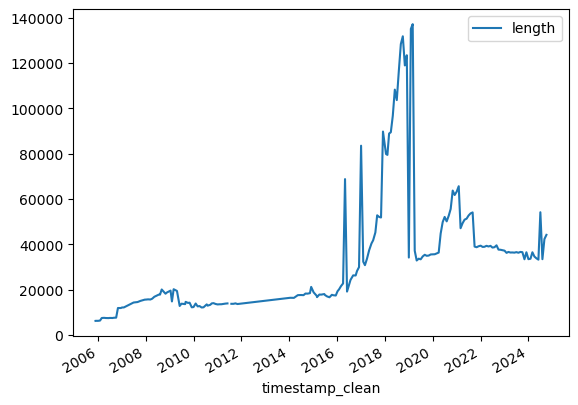

In [28]:
cdx_df.plot.line(x='timestamp_clean',y='length')

Let's abstract this into a function we can use more generally.

In [29]:
def retrieve_wayback_cdx_df(url):
    # Write the query string
    cdx_url_query = 'http://web.archive.org/cdx/search/cdx?url={0}&limit=1000&output=json&collapse=timestamp:6&filter=statuscode:200'
    
    # Make the request
    r = requests.get(
        url = cdx_url_query.format(url),
        headers = {'User-Agent':'info-5871/0.1 Web Data Science, brian.keegan@colorado.edu'}
    )
    
    # Turn the list of lists into a DataFrame, starting at the 2nd list
    df = pd.DataFrame.from_records(r.json()[1:])
    
    # Make the 1st list the column names
    df.columns = r.json()[0]
    
    # Convert the timestamp column into Timestamp objects
    df['timestamp_clean'] = pd.to_datetime(df['timestamp'],format='%Y%m%d%H%M%S')
    
    # Replace and cast the statuscode and length columns to integers
    df[['statuscode','length']] = df[['statuscode','length']].replace({'-':np.nan}).astype(pd.Int32Dtype())
    
    # Inspect
    return df

Test on the `fb_pp` Privacy Policy snapshots.

In [30]:
fb_pp_df = retrieve_wayback_cdx_df(fb_pp)

fb_pp_df.head()

,urlkey,timestamp,original,mimetype,statuscode,digest,length,timestamp_clean
0,"com,facebook)/policy.php",20050809235134,http://www.facebook.com:80/policy.php,text/html,200,QE2ILX5EOZXSAHEJPXYWN6DSAUMWO6ZH,4212,2005-08-09 23:51:34
1,"com,facebook)/policy.php",20051125142633,http://www.facebook.com:80/policy.php,text/html,200,FYSB4GOC3MML4UCCXF6SVUM5TLTZ3WDR,4149,2005-11-25 14:26:33
2,"com,facebook)/policy.php",20051201053003,http://www.facebook.com:80/policy.php,text/html,200,6MJGB6SVZTIFIABRHUHAVDGUPEJD5XII,4166,2005-12-01 05:30:03
3,"com,facebook)/policy.php",20060104033618,http://www.facebook.com:80/policy.php,text/html,200,X2HBT6WEQ5IZU7ZIY3OBMD7A4GTDQZTZ,4166,2006-01-04 03:36:18
4,"com,facebook)/policy.php",20060206205518,http://www.facebook.com:80/policy.php,text/html,200,JHWZ6I65KOUWJZBIO2LCXC5VIZHA5MMZ,4244,2006-02-06 20:55:18


Visualize

<Axes: xlabel='timestamp_clean'>

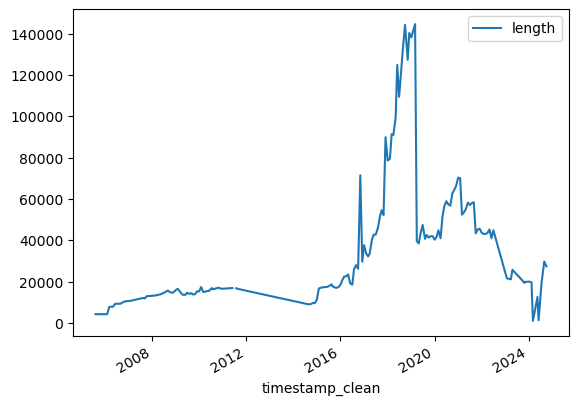

In [31]:
fb_pp_df.plot.line(x='timestamp_clean',y='length')

We could compare the evolution of both policies' sizes. The `Grouper` function ([docs](https://pandas.pydata.org/docs/reference/api/pandas.Grouper.html)) is a powerful tool for working with temporal data. In this case, the timestamps of snapshots don't line up precisely at the same second, hour, or date. Using the `Grouper` function within the `groupby` we are able to sample the "timestamp_clean" data at a monthly frequency.

In [32]:
cdx_df.head(2)

,urlkey,timestamp,original,mimetype,statuscode,digest,length,timestamp_clean
0,"com,facebook)/terms.php",20051126052914,http://www.facebook.com:80/terms.php,text/html,200,MRI7NEPTXI3IFWNDHAGT7YCEQQUDTJ3X,6246,2005-11-26 05:29:14
1,"com,facebook)/terms.php",20051201023517,http://www.facebook.com:80/terms.php,text/html,200,YSLIFIJ2RELRCFT2E2RFKTMJC4PR6SF5,6268,2005-12-01 02:35:17


In [ ]:
tos_monthly_length

<Axes: xlabel='timestamp_clean'>

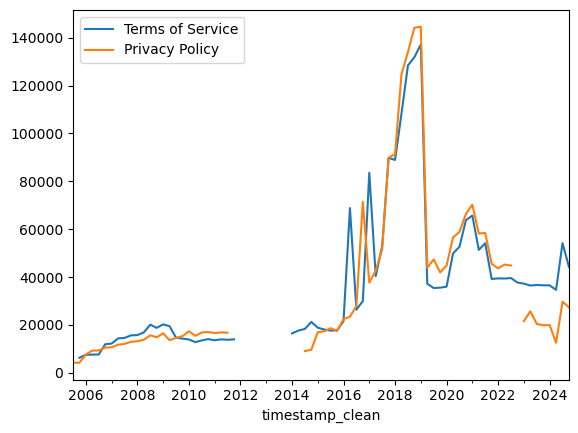

In [33]:
tos_monthly_length = cdx_df.groupby(pd.Grouper(key='timestamp_clean',freq='1QS')).agg({'length':'max'})
tos_monthly_length.rename(columns={'length':'Terms of Service'},inplace=True)

pp_monthly_length = fb_pp_df.groupby(pd.Grouper(key='timestamp_clean',freq='1QS')).agg({'length':'max'})
pp_monthly_length.rename(columns={'length':'Privacy Policy'},inplace=True)

combined_monthly_length = pd.concat([tos_monthly_length,pp_monthly_length],axis='columns')

combined_monthly_length.plot()

## Retrieving historical content

I don't completely trust the "length" values recorded from the CDX database given the unusually strong similarity between the Facebook Privacy Policy and Terms of Service pages. I want to look at these documents and compute my own statistics and do other analyses.

To start, let's try to retrieve the historical content of some of these pages using the data we got from the Wayback CDX server. Using string formatting ([docs](https://docs.python.org/3/tutorial/inputoutput.html#the-string-format-method)), we can populate the fields of a Wayback Machine URL from the `fb_pp_df` CDF DataFrame contents to get the archived version of a page by entering the specific timestamp and page URL into the Wayback URL. This is the first (oldest) version returned from the `fb_pp_df`. Click/copy the link to make sure the Wayback URL works.

In [34]:
'http://web.archive.org/web/{timestamp}/{original}'.format(
    timestamp = fb_pp_df.loc[0,'timestamp'],
    original = fb_pp_df.loc[0,'original']
)

'http://web.archive.org/web/20050809235134/http://www.facebook.com:80/policy.php'

Repeat the steps from above of using `requests` to get the contents, use `BeautifulSoup` to convert the raw HTML, and then getting the content of the page.

In [35]:
# Find the old URL
fb_old_url = 'http://web.archive.org/web/{timestamp}/{original}'.format(
    timestamp = fb_pp_df.loc[0,'timestamp'],
    original = fb_pp_df.loc[0,'original']
)

# Go get the archived snapshot from the Wayback Machine
fb_raw = requests.get(fb_old_url).text

# Soup-ify
fb_soup = BeautifulSoup(fb_raw)

# Find the content element and get the text out
fb_str = fb_soup.find('center').text

# Inspect
print(fb_str[200:])

 is effective as of June 28, 2005.
Introduction Thefacebook Privacy Policy is designed to assist you in understanding how we collect and use the personal information that you provide to us and to assist you in making informed decisions when using Thefacebook web site located at www.thefacebook.com (the "Web Site"). 
The Information We Collect When you visit the Web Site you may provide us with two types of information: personal information you knowingly choose to disclose that is collected by us and Web Site use information collected by us on an aggregate basis as you and others browse our Web Site.  
When you register on the Web Site, you provide us with certain personal information, such as your name, your email address, your telephone number, your address, your gender, schools attended and any other personal or preference information that you provide to us.
When you enter our Web Site, we collect the user's browser type and IP address. This information is gathered for all users to t

We could do a simple word count on this document splitting on white space and line separators.

In [36]:
len(fb_str.split())

1025

Now let's try to get all the pages' content. We'll use a combination of string formatting and pandas apply to take the data present in the "timestamp" and "original" columns to fill in the `wayback_url_pattern` and return a pandas Series with populated URLs.

In [ ]:
fb_pp_df

In [37]:
wayback_url_pattern = 'http://web.archive.org/web/{timestamp}/{original}'

# https://stackoverflow.com/a/49122977/1574687
populated_archived_urls = fb_pp_df.apply(lambda x:wayback_url_pattern.format(**x),1)

# Set the index to be the timestamp_clean column
populated_archived_urls.index = fb_pp_df['timestamp_clean']

populated_archived_urls.head(10)

timestamp_clean
2005-08-09 23:51:34    http://web.archive.org/web/20050809235134/http...
2005-11-25 14:26:33    http://web.archive.org/web/20051125142633/http...
2005-12-01 05:30:03    http://web.archive.org/web/20051201053003/http...
2006-01-04 03:36:18    http://web.archive.org/web/20060104033618/http...
2006-02-06 20:55:18    http://web.archive.org/web/20060206205518/http...
2006-03-10 00:32:54    http://web.archive.org/web/20060310003254/http...
2006-04-06 03:52:27    http://web.archive.org/web/20060406035227/http...
2006-05-05 20:26:11    http://web.archive.org/web/20060505202611/http...
2006-06-13 19:59:16    http://web.archive.org/web/20060613195916/http...
2006-07-05 12:39:14    http://web.archive.org/web/20060705123914/http...
dtype: object

Loop through each of these URLs, get the page content, and store it so we can use it later.

In [38]:
# Dictionary to store the data
fb_pp_historical_content_d = {}

# Loop through the URLs populated from CDX data
for timestamp,snapshot_url in populated_archived_urls.to_dict().items():

    # Simplify the timestamp
    simplified_ts = str(timestamp.date())
    
    # Get the snapshot URL from the Wayback Machine and store in the dictionary
    fb_pp_historical_content_d[simplified_ts] = requests.get(snapshot_url).text

    # Sleep for a second between each request to not overload the server
    sleep(1)

ConnectionError: HTTPConnectionPool(host='web.archive.org', port=80): Max retries exceeded with url: /web/20070630042429/http://www.facebook.com/policy.php (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x17afe2820>: Failed to establish a new connection: [Errno 61] Connection refused'))

In [39]:
len(fb_pp_historical_content_d)

17

Serialize this data down so we don't have to scrape it again.

In [ ]:
with open('facebook_privacy_policy_historical.json','w') as f:
    json.dump(fb_pp_historical_content_d,f)

Load the JSON file with all the content.

In [40]:
with open('facebook_privacy_policy_historical.json','r') as f:
    fb_pp_historical_content_d = json.load(f)

len(fb_pp_historical_content_d)

158

Try to generate word counts for each version of the document.

In [42]:
list(fb_pp_historical_content_d.values())[-1]

'<!DOCTYPE html>\n<html lang="en" id="facebook" class="no_js">\n<head><script type="text/javascript" src="/_static/js/bundle-playback.js?v=1WaXNDFE" charset="utf-8"></script>\n<script type="text/javascript" src="/_static/js/wombat.js?v=txqj7nKC" charset="utf-8"></script>\n<script>window.RufflePlayer=window.RufflePlayer||{};window.RufflePlayer.config={"autoplay":"on","unmuteOverlay":"hidden"};</script>\n<script type="text/javascript" src="/_static/js/ruffle.js"></script>\n<script type="text/javascript">\n  __wm.init("http://web.archive.org/web");\n  __wm.wombat("http://www.facebook.com/POLICY.PHP","20230423014046","http://web.archive.org/","web","/_static/",\n\t      "1682214046");\n</script>\n<link rel="stylesheet" type="text/css" href="/_static/css/banner-styles.css?v=S1zqJCYt" />\n<link rel="stylesheet" type="text/css" href="/_static/css/iconochive.css?v=qtvMKcIJ" />\n<!-- End Wayback Rewrite JS Include -->\n<meta charset="utf-8"/><meta name="referrer" content="origin-when-crossorigi

In [43]:
fb_pp_historical_wc = {}

for timestamp,text in fb_pp_historical_content_d.items():
    # Soup-ify
    soup = BeautifulSoup(text)

    # Find the content element and get the text out This is extremely brittle code!
    # Try to find content in the <body> tag
    try:
        non_wb_content = soup.find('body').text

    # If a <body> is not present, try to find a <div id="content">
    except AttributeError:
        non_wb_content = soup.find('div',{'id':'content'}).text

    # Count the words
    fb_pp_historical_wc[timestamp] = len(non_wb_content.split())

In [44]:
fb_pp_historical_wc

{'2005-08-09': 1025,
 '2005-11-25': 1164,
 '2005-12-01': 1164,
 '2006-01-04': 1163,
 '2006-02-06': 1164,
 '2006-03-10': 2312,
 '2006-04-06': 2314,
 '2006-05-05': 2303,
 '2006-06-13': 2688,
 '2006-07-05': 2688,
 '2006-08-13': 2688,
 '2006-09-03': 2688,
 '2006-10-07': 2823,
 '2006-11-05': 3068,
 '2006-12-05': 3074,
 '2007-01-03': 3075,
 '2007-02-02': 3078,
 '2007-06-30': 3505,
 '2007-08-30': 3501,
 '2007-09-11': 3501,
 '2007-10-11': 3511,
 '2008-02-13': 3687,
 '2008-05-12': 3687,
 '2008-07-19': 3693,
 '2008-08-07': 3693,
 '2008-09-02': 3693,
 '2008-10-11': 3687,
 '2008-11-20': 3289,
 '2009-01-14': 3721,
 '2009-02-05': 3721,
 '2009-03-20': 3761,
 '2009-04-22': 3751,
 '2009-06-03': 3726,
 '2009-07-01': 3728,
 '2009-08-05': 3727,
 '2009-09-01': 3724,
 '2009-10-01': 3724,
 '2009-11-03': 3726,
 '2009-12-04': 5425,
 '2010-01-01': 5472,
 '2010-02-02': 6297,
 '2010-03-05': 5547,
 '2010-04-02': 5563,
 '2010-05-04': 5927,
 '2010-06-03': 5895,
 '2010-08-06': 5912,
 '2010-09-13': 5912,
 '2010-10-03'

Visualize the results. We still have a big gap in the data and some troubling instances of likely missing/incomplete data.

/var/folders/lr/v195xr617d32k2zdwwh30sb40000gn/T/ipykernel_93473/2360955122.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fb_pp_historical_wc_s = fb_pp_historical_wc_s.groupby(pd.Grouper(freq='1M')).max()


Text(0, 0.5, 'Word count')

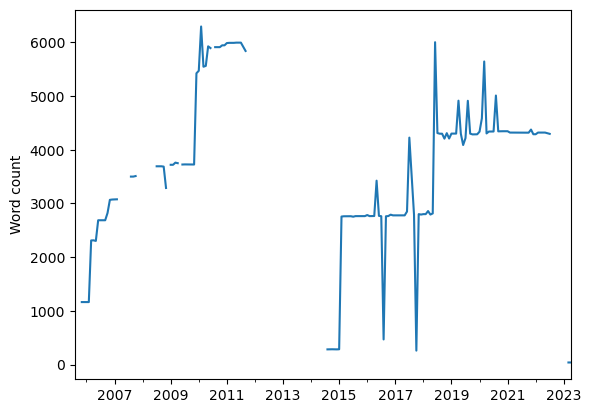

In [45]:
# Convert the dictionary into a pandas Series
fb_pp_historical_wc_s = pd.Series(fb_pp_historical_wc)

# Convert the timestamps in the index from strings into true Timestamp objects
fb_pp_historical_wc_s.index = pd.to_datetime(fb_pp_historical_wc_s.index)

# Clean up the data so we have regular monthly observations
fb_pp_historical_wc_s = fb_pp_historical_wc_s.groupby(pd.Grouper(freq='1M')).max()

# Plot
ax = fb_pp_historical_wc_s.plot()
ax.set_ylabel('Word count')

## Document similarity (bag-of-words)

Let's apply some more advanced natural language processing methods that just counting words. First, we will use a naive "bag of words" method to calculate the similarity of historical documents to the current document.

With any kind of natural language processing, there's a lot of preprocessing work to clean up the data. We are going to use a natural language processing library called "[gensim](https://radimrehurek.com/gensim/)" to analyze our web text data.

In [ ]:
! conda install --yes -c conda-forge gensim

In [46]:
from gensim.utils import simple_preprocess

from gensim.parsing.preprocessing import STOPWORDS as stopwords
from gensim.parsing.preprocessing import preprocess_string

from gensim import corpora, models, similarities

Check out the `stopwords`

In [ ]:
stopwords

The steps are roughly:
1. Turn our webpage into a text document
2. Split the document up into tokens (words)
3. Filter out common words and punctuation
4. Convert our collection of words to a numeric representation of a document
5. Compare the numeric representations of documents.
  
A lot of steps! First, convert our webpage into a text document. Convert the raw HTML string into Soup and look for a `<body>` tag. We may need to develop more sophisticated or alternative methods for retrieving the content of pages that varies by webpage version. Or in our case, be content with a simple but dump approach.

In [47]:
first_example_soup = BeautifulSoup(fb_pp_historical_content_d['2005-08-09'])
first_example_text = first_example_soup.find_all('body')[0].text

print(first_example_text)









 

 login
 register
 about
 faq
 












                  Email:                   Password:

 
                          








Thefacebook Privacy Policy[ Privacy Policy ]This policy is effective as of June 28, 2005.
Introduction Thefacebook Privacy Policy is designed to assist you in understanding how we collect and use the personal information that you provide to us and to assist you in making informed decisions when using Thefacebook web site located at www.thefacebook.com (the "Web Site"). 
The Information We Collect When you visit the Web Site you may provide us with two types of information: personal information you knowingly choose to disclose that is collected by us and Web Site use information collected by us on an aggregate basis as you and others browse our Web Site.  
When you register on the Web Site, you provide us with certain personal information, such as your name, your email address, your telephone number, your address, your gender, schools attended 

In [48]:
last_example_soup = BeautifulSoup(fb_pp_historical_content_d['2022-07-01'])
last_example_text = last_example_soup.find_all('body')[0].text

print(last_example_text)

FacebookEmail or phonePasswordForgot account?Sign UpFull Data Policy We've updated our policy. Read it here.  Facebook Ads Controls  Privacy Basics  Cookies Policy  Terms  More Resources  View a printable version of the Data Policy  Interactive Tools  Minors and Safety  Facebook Privacy Page  Facebook Safety Page  Facebook Site Governance Page  EU-U.S. Privacy Shield and Swiss-U.S. Privacy Shield Notice The Facebook company is now Meta. We’ve updated our Terms of Use, Data Policy, and Cookies Policy to reflect the new name on January 4, 2022. While our company name has changed, we are continuing to offer the same products, including the Facebook app from Meta. Our Data Policy and Terms of Service remain in effect, and this name change does not affect how we use or share data. Learn more about Meta and our vision for the metaverse.Data Policy This policy describes the information we process to support Facebook, Instagram, Messenger and other products and features offered by Meta Platfor

Second, we will split the document up into tokens. We'll use an existing function like gensim's `simple_preprocess` ([docs](https://radimrehurek.com/gensim/utils.html#gensim.utils.simple_preprocess)) to tokenize and covert the words all to lower-case. 

In [49]:
first_text_preprocessed = simple_preprocess(first_example_text)
last_text_preprocessed = simple_preprocess(last_example_text)

first_text_preprocessed[:20]

['login',
 'register',
 'about',
 'faq',
 'email',
 'password',
 'thefacebook',
 'privacy',
 'policy',
 'privacy',
 'policy',
 'this',
 'policy',
 'is',
 'effective',
 'as',
 'of',
 'june',
 'introduction',
 'thefacebook']

Third, we will filter out common stopwords like "the", "of", etc. using NTLK's English stopwords list.

In [50]:
first_text_cleaned = [word for word in first_text_preprocessed if word not in stopwords]
last_text_cleaned = [word for word in last_text_preprocessed if word not in stopwords]

first_text_cleaned[:20]

['login',
 'register',
 'faq',
 'email',
 'password',
 'thefacebook',
 'privacy',
 'policy',
 'privacy',
 'policy',
 'policy',
 'effective',
 'june',
 'introduction',
 'thefacebook',
 'privacy',
 'policy',
 'designed',
 'assist',
 'understanding']

Fourth, we convert our documents into a Dictionary that maps words to IDs and then use a bag-of-words.

In [51]:
example_text_dictionary = corpora.Dictionary([first_text_cleaned,last_text_cleaned])

# Inspect with the token2id attribute
example_text_dictionary.token2id

{'access': 0,
 'account': 1,
 'activities': 2,
 'addition': 3,
 'additionally': 4,
 'address': 5,
 'advertise': 6,
 'advertisement': 7,
 'advertisements': 8,
 'advertisers': 9,
 'advertising': 10,
 'agencies': 11,
 'agents': 12,
 'aggregate': 13,
 'allows': 14,
 'announce': 15,
 'appear': 16,
 'applicable': 17,
 'applies': 18,
 'appropriate': 19,
 'assist': 20,
 'attended': 21,
 'available': 22,
 'aware': 23,
 'basis': 24,
 'believe': 25,
 'belong': 26,
 'bring': 27,
 'browse': 28,
 'browser': 29,
 'business': 30,
 'certain': 31,
 'change': 32,
 'changes': 33,
 'changing': 34,
 'choice': 35,
 'choose': 36,
 'clicked': 37,
 'close': 38,
 'collect': 39,
 'collected': 40,
 'collects': 41,
 'com': 42,
 'communication': 43,
 'companies': 44,
 'compile': 45,
 'compliance': 46,
 'comply': 47,
 'confirm': 48,
 'connection': 49,
 'contact': 50,
 'contacting': 51,
 'contain': 52,
 'control': 53,
 'cookie': 54,
 'cookies': 55,
 'court': 56,
 'cover': 57,
 'covers': 58,
 'create': 59,
 'current': 

Use the dictionary to turn each document into a bag of words.

In [52]:
example_text_bow = [example_text_dictionary.doc2bow(text) for text in [first_text_cleaned,last_text_cleaned]]

# Inspect a document's BOW representation
example_text_bow[1]

[(0, 11),
 (1, 17),
 (2, 5),
 (5, 5),
 (9, 5),
 (13, 2),
 (17, 2),
 (19, 1),
 (22, 1),
 (29, 1),
 (30, 8),
 (31, 1),
 (32, 2),
 (33, 3),
 (34, 1),
 (36, 13),
 (39, 13),
 (40, 3),
 (44, 6),
 (48, 1),
 (49, 2),
 (50, 10),
 (53, 4),
 (54, 3),
 (55, 9),
 (56, 1),
 (59, 3),
 (60, 1),
 (61, 1),
 (62, 32),
 (63, 2),
 (64, 1),
 (65, 1),
 (69, 1),
 (71, 2),
 (74, 2),
 (78, 19),
 (85, 1),
 (86, 3),
 (87, 9),
 (88, 1),
 (92, 6),
 (93, 25),
 (96, 110),
 (99, 2),
 (101, 2),
 (105, 6),
 (106, 1),
 (107, 1),
 (113, 1),
 (115, 2),
 (118, 1),
 (122, 3),
 (123, 3),
 (124, 4),
 (127, 5),
 (128, 1),
 (130, 1),
 (133, 3),
 (135, 2),
 (136, 1),
 (137, 6),
 (138, 2),
 (139, 19),
 (140, 11),
 (142, 25),
 (144, 1),
 (145, 4),
 (148, 19),
 (149, 2),
 (150, 6),
 (154, 9),
 (157, 4),
 (159, 1),
 (160, 1),
 (161, 34),
 (162, 3),
 (163, 5),
 (165, 2),
 (166, 1),
 (167, 15),
 (169, 1),
 (174, 1),
 (176, 3),
 (177, 4),
 (178, 1),
 (186, 4),
 (187, 6),
 (189, 5),
 (190, 19),
 (192, 15),
 (193, 36),
 (194, 2),
 (195, 1

We compute a term frequency-inverse document frequency model on these documents' bags of words to get a sense of their relative frequency.

In [53]:
example_tfidf = models.TfidfModel(example_text_bow)

Compute the similarity matrix for a document against the model.

In [54]:
example_similarity = similarities.MatrixSimilarity(example_tfidf[example_text_bow])
example_similarity[example_text_bow]

array([[0.41031253, 0.        ],
       [0.        , 0.6116781 ]], dtype=float32)

### All documents
Now let's train our BoW-TFIDF model on all the privacy policies.

In [55]:
wayback_documents_cleaned = []

# For each historical snapshot's content
for timestamp,content in fb_pp_historical_content_d.items():

    # Turn each content into soup
    soup = BeautifulSoup(content)

    # Retrieve the content in the body of the document
    body = soup.find_all('body')[0].text

    # Pre-process the body into a list of tokens
    preprocessed = simple_preprocess(body)

    # Remove stopwords
    cleaned = [word for word in preprocessed if word not in stopwords]

    # As long as there are words in the document
    if len(cleaned) > 0:
        
        # Add to list of documents
        wayback_documents_cleaned.append(cleaned)

print(len(wayback_documents_cleaned))

158


Make the bags-of-words for each document in `wayback_documents_cleaned`

In [56]:
wayback_dictionary = corpora.Dictionary(wayback_documents_cleaned)

wayback_bow = [wayback_dictionary.doc2bow(text) for text in wayback_documents_cleaned]

wayback_tfidf = models.TfidfModel(wayback_bow)

wayback_similarity = similarities.MatrixSimilarity(wayback_tfidf[wayback_bow])

Pass a bag-of-words vector for a document into the similarity matrix to get the pairwise cosine similarities to the other N-1 documents.

In [57]:
wayback_similarity[wayback_bow[0]]

array([4.2086723e-01, 4.8692894e-01, 4.8692894e-01, 4.8956674e-01,
       4.9247795e-01, 4.1106421e-01, 4.1147941e-01, 4.0985924e-01,
       4.0432954e-01, 4.0401843e-01, 4.0401843e-01, 4.0105441e-01,
       3.9704579e-01, 4.0836132e-01, 4.0742946e-01, 4.0834826e-01,
       4.0647453e-01, 3.4534347e-01, 3.4503636e-01, 3.4503636e-01,
       3.4578848e-01, 3.4393322e-01, 3.4475809e-01, 3.4413853e-01,
       3.4413853e-01, 3.4413853e-01, 3.4350848e-01, 3.3069441e-01,
       3.3984977e-01, 3.3984977e-01, 3.3454585e-01, 3.3934832e-01,
       3.4531483e-01, 3.4511486e-01, 3.4411919e-01, 3.4497797e-01,
       3.4497797e-01, 3.4538126e-01, 2.5214019e-01, 2.4624923e-01,
       2.6476197e-03, 2.5189796e-01, 2.5135064e-01, 2.5683653e-01,
       2.4804232e-01, 2.4843433e-01, 2.4843433e-01, 2.4843433e-01,
       2.4554156e-01, 2.4554156e-01, 2.5023437e-01, 2.5022936e-01,
       2.5022936e-01, 2.5022936e-01, 2.5028136e-01, 2.5028136e-01,
       2.5028136e-01, 2.4748521e-01, 2.5163275e-01, 4.7717698e

The first document is likely to be similar to other early documents and then decrease over time

(0.0, 0.6)

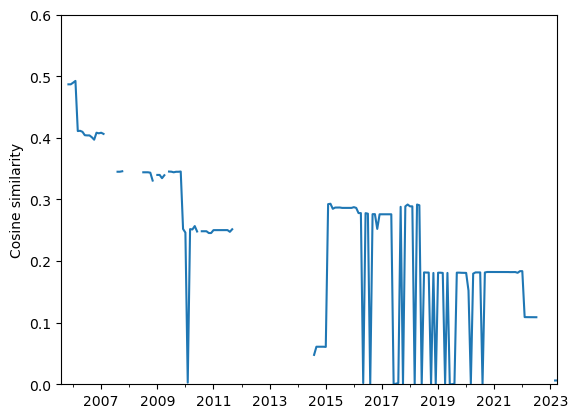

In [58]:
# Put the data into a Series
s = pd.Series(
    data = wayback_similarity[wayback_bow[0]],
    index = pd.to_datetime(list(fb_pp_historical_content_d.keys()))
)

# Use a Grouper to reindex to the start of each month
s = s.groupby(pd.Grouper(freq='MS')).max()

# Visualize
ax = s.plot()
ax.set_ylabel('Cosine similarity')
ax.set_ylim((0,.6))

We could also make a heatmap of the document-document similarities.

<Axes: >

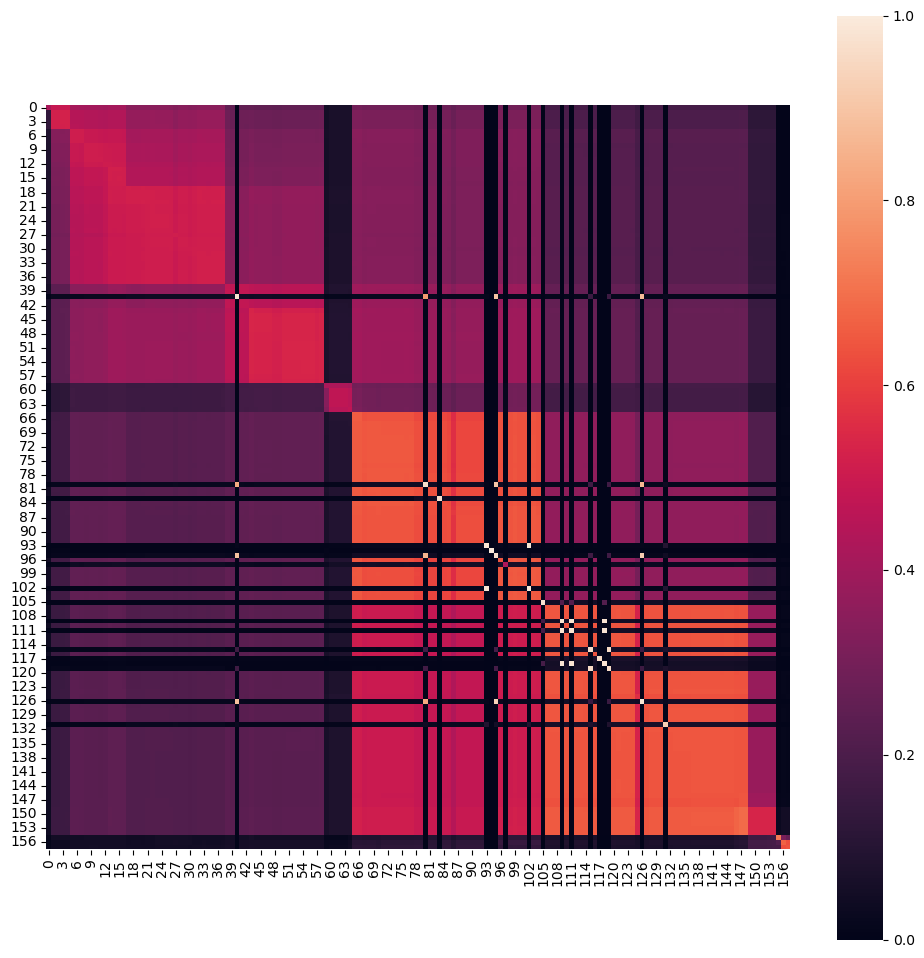

In [59]:
f,ax = plt.subplots(figsize=(12,12))

sb.heatmap(
    data = wayback_similarity[wayback_bow],
    ax = ax,
    square = True,
    vmin = 0,
    vmax = 1,
)

## Exercises

### Exercise 01: Find an interesting website archive
The front pages of popular websites (Amazon, CNN, etc.) may have a lot of coverage but are likely to change significantly and be complicated to parse. Find a simpler web page and check the Wayback Machine for its coverage.

### Exercise 02: Retrieve data and test a scraper
Query the Wayback API to find an early and more recent version of a website. Write a test scraper to ensure you can retrieve the content of both versions.

### Exercise 03: Retrieve archive data from the CDX server
Retrieve monthly-frequency snapshots from the CDX server using the `cdx_url_query` for your website. Change some of the parameters of the CDX query and see what data you get back.

### Exercise 04: Retrieve and analyze historical web content
Retrieve the historical content (at something like a monthly frequency) using the CDX query from the Wayback Machine. Write a simple parser to find the core article content, count the number of words in each snapshot, and visualize the results.

### ADVANCED Exerise 05: Analyze document similarity
Using the historical article content, create a TFIDF model of all the documents. Use `MatrixSimilarity` to compute the pairwise similarities between documents. Visualize the similarity of a single document changing over time.

## Appendix: Older code
Write a loop to find a snapshot of Facebook's ToS each month in our `dates_list`. 

In [ ]:
def get_urls(url_str,start_date='2005-01-01',end_date='2021-10-01',freq='M',useragent='info-5871/0.1 Web Data Science, brian.keegan@colorado.edu'):
    
    # Make the list of dates
    date_l = pd.date_range(start_date,end_date,freq=freq)
    
    # Create an empty container to store our data
    urls = dict()

    # For each date in the list of dates
    for date in date_l:
        
        # Turn the date object back into a string
        date_str = datetime.strftime(date,'%Y%m%d%H%M%S')
        
        # Define the API URL request to the Wayback machine
        wb_api_url = 'http://archive.org/wayback/available?url={0}&timestamp={1}'
        
        # Format the API URL with the URL of the website and the closest datetime
        wb_api_request = wb_api_url.format(url_str,date_str)
        
        # Make the request
        try:
            r = requests.get(wb_api_request,headers={'User-Agent':useragent}).json()
        except json.JSONDecodeError:
            r = {}

        # Check if the returned request has all the right parts (this is probably overkill)
        if 'archived_snapshots' in r.keys():
            if 'closest' in r['archived_snapshots'].keys():
                if 'url' in r['archived_snapshots']['closest'].keys():
                    
                    # If it does have all the right parts, get the URL
                    _url = r['archived_snapshots']['closest']['url']
                    
                    # Get the timestamp
                    _timestamp = r['archived_snapshots']['closest']['timestamp']
                    
                    # Save to our URL dictionary with the timestamp of the snapshot as key, the url as value
                    urls[_timestamp] = _url
    return urls

Run our function to make a dictionary of keys returning the Wayback Machine URLs for each month's version of the terms of service. We'll write a loop to get the Terms for each snapshot and count the words. 

This will take a few minutes.  I've coverted the code block into a "Raw" cell to prevent accidental execution. You can always turn it into a "Code" cell if you really want to run it.

In [ ]:
# Get the list of timestamps and URLs for each monthly version of the Terms of Service
fb_terms_d = get_urls('https://www.facebook.com/terms.php')

# Create an empty container to store our data
fb_terms_wordcount = {}

# Loop through the fb_terms_d dictionary
for timestamp,url in fb_terms_d.items():

    # Get the raw HTML from the Wayback Machine
    raw = requests.get(url).text
    
    # Soup-ify
    soup = BeautifulSoup(raw)
    
    # Find the content of the TOS
    content = soup.find('div',{'id':'content'}).text.strip()
    
    # Split the content into words, count the number of words, save to the container
    fb_terms_wordcount[timestamp] = len(content.split())
    
# Write to disk
with open('facebook_tos_archive.json','w') as f:
    json.dump(fb_terms_wordcount,f)